In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [20]:
#Loading the Dataset
fear_df = pd.read_csv(
    '/kaggle/input/datasets/nagasaiparaksh/task-dataset/fear_greed_index.csv'
)

historical_df = pd.read_csv(
    '/kaggle/input/datasets/nagasaiparaksh/task-dataset/historical_data.csv'
)


In [21]:
fear_df.columns = (
    fear_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

historical_df.columns = (
    historical_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

print("Fear Dataset Columns:")
print(fear_df.columns.tolist())

print("\nHistorical Dataset Columns:")
print(historical_df.columns.tolist())

Fear Dataset Columns:
['timestamp', 'value', 'classification', 'date']

Historical Dataset Columns:
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']


In [22]:
print("\nFear & Greed Dataset")
print(fear_df.head())

print("\nHistorical Dataset")
print(historical_df.head())




Fear & Greed Dataset
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Historical Dataset
                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side     timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2     

In [23]:
print("\nMissing Values - Fear Dataset")
print(fear_df.isnull().sum())

print("\nMissing Values - Historical Dataset")
print(historical_df.isnull().sum())



Missing Values - Fear Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values - Historical Dataset
account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
dtype: int64


In [24]:
fear_df['date'] = pd.to_datetime(
    fear_df['date']
)

fear_df['classification'] = (
    fear_df['classification']
    .astype(str)
    .str.strip()
)

print("\nFear Dataset Cleaned")
print(fear_df.head())



Fear Dataset Cleaned
    timestamp  value classification       date
0  1517463000     30           Fear 2018-02-01
1  1517549400     15   Extreme Fear 2018-02-02
2  1517635800     40           Fear 2018-02-03
3  1517722200     24   Extreme Fear 2018-02-04
4  1517808600     11   Extreme Fear 2018-02-05


In [25]:
# Convert timestamp column properly
historical_df['timestamp_ist'] = pd.to_datetime(
    historical_df['timestamp_ist'],
    format='%d-%m-%Y %H:%M'
)

# Remove duplicates
historical_df = historical_df.drop_duplicates()

print("\nHistorical Dataset Cleaned")
print(historical_df.head())



Historical Dataset Cleaned
                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side       timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   closed_pnl                                   transaction_hash

In [26]:
historical_df['trade_date'] = (
    historical_df['timestamp_ist']
    .dt.date
)

fear_df['date'] = fear_df['date'].dt.date

In [27]:
sentiment_map = {
    'Extreme Fear': 0,
    'Fear': 1,
    'Neutral': 2,
    'Greed': 3,
    'Extreme Greed': 4
}

fear_df['sentiment_score'] = (
    fear_df['classification']
    .map(sentiment_map)
)

print("\nFear Dataset with Sentiment Score")
print(fear_df.head())


Fear Dataset with Sentiment Score
    timestamp  value classification        date  sentiment_score
0  1517463000     30           Fear  2018-02-01                1
1  1517549400     15   Extreme Fear  2018-02-02                0
2  1517635800     40           Fear  2018-02-03                1
3  1517722200     24   Extreme Fear  2018-02-04                0
4  1517808600     11   Extreme Fear  2018-02-05                0


In [28]:
merged_df = historical_df.merge(
    fear_df,
    left_on='trade_date',
    right_on='date',
    how='left'
)

print("\nMerged Dataset")
print(merged_df.head())


Merged Dataset
                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side       timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   closed_pnl  ... crossed       fee      trade_id   timestamp_x  trade_date

In [29]:
print("\nMissing Values After Merge")
print(
    merged_df[
        ['classification', 'sentiment_score']
    ].isnull().sum()
)


Missing Values After Merge
classification     6
sentiment_score    6
dtype: int64


In [30]:
merged_df = merged_df.dropna(
    subset=['classification']
)

print("\nDataset Shape After Cleaning:")
print(merged_df.shape)




Dataset Shape After Cleaning:
(211218, 22)


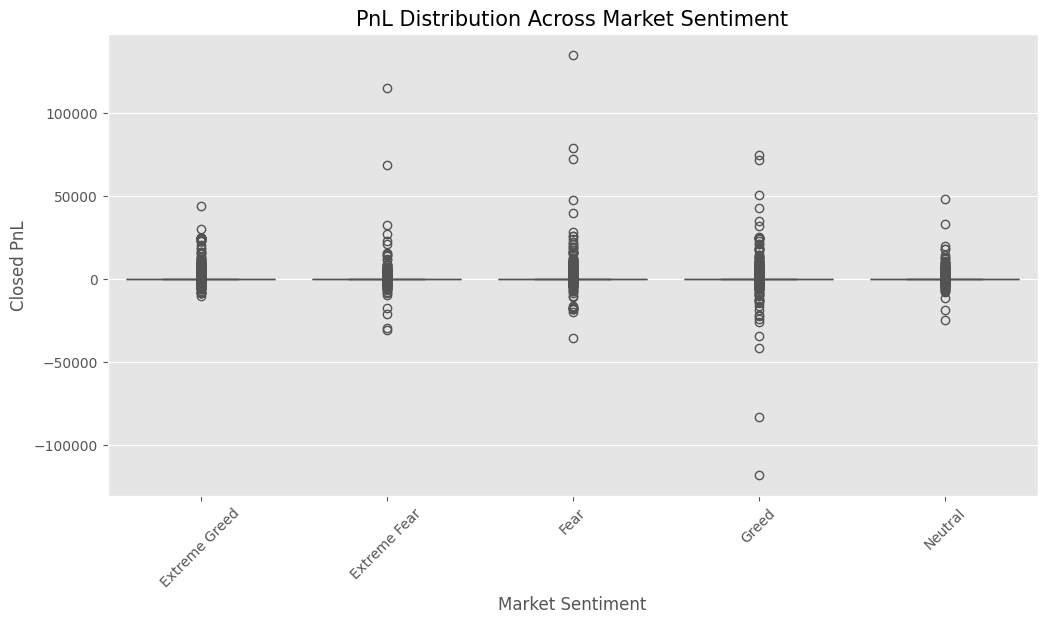

In [31]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='classification',
    y='closed_pnl',
    data=merged_df
)

plt.title(
    'PnL Distribution Across Market Sentiment',
    fontsize=15
)

plt.xlabel('Market Sentiment')

plt.ylabel('Closed PnL')

plt.xticks(rotation=45)

plt.show()


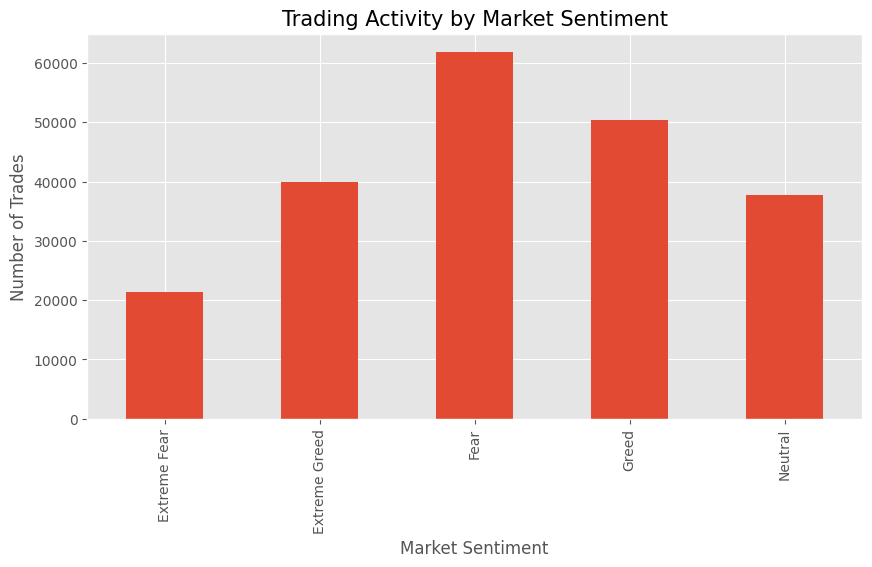

In [32]:
plt.figure(figsize=(10,5))

activity = merged_df.groupby(
    'classification'
).size()

activity.plot(kind='bar')

plt.title(
    'Trading Activity by Market Sentiment',
    fontsize=15
)

plt.xlabel('Market Sentiment')

plt.ylabel('Number of Trades')

plt.show()


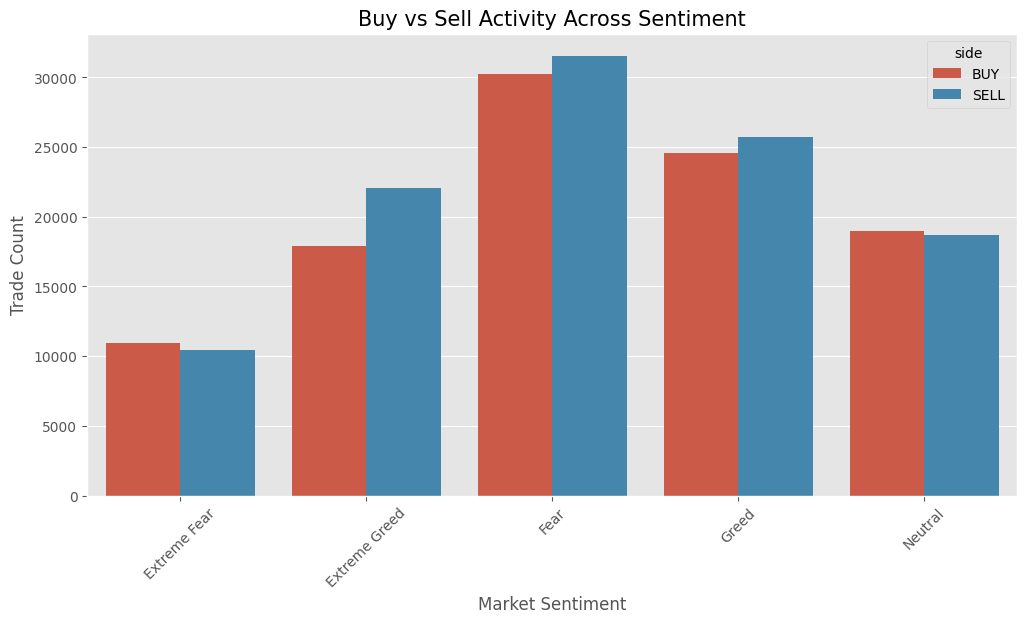

In [33]:
side_counts = merged_df.groupby(
    ['classification', 'side']
).size().reset_index(name='count')

plt.figure(figsize=(12,6))

sns.barplot(
    x='classification',
    y='count',
    hue='side',
    data=side_counts
)

plt.title(
    'Buy vs Sell Activity Across Sentiment',
    fontsize=15
)

plt.xlabel('Market Sentiment')

plt.ylabel('Trade Count')

plt.xticks(rotation=45)

plt.show()

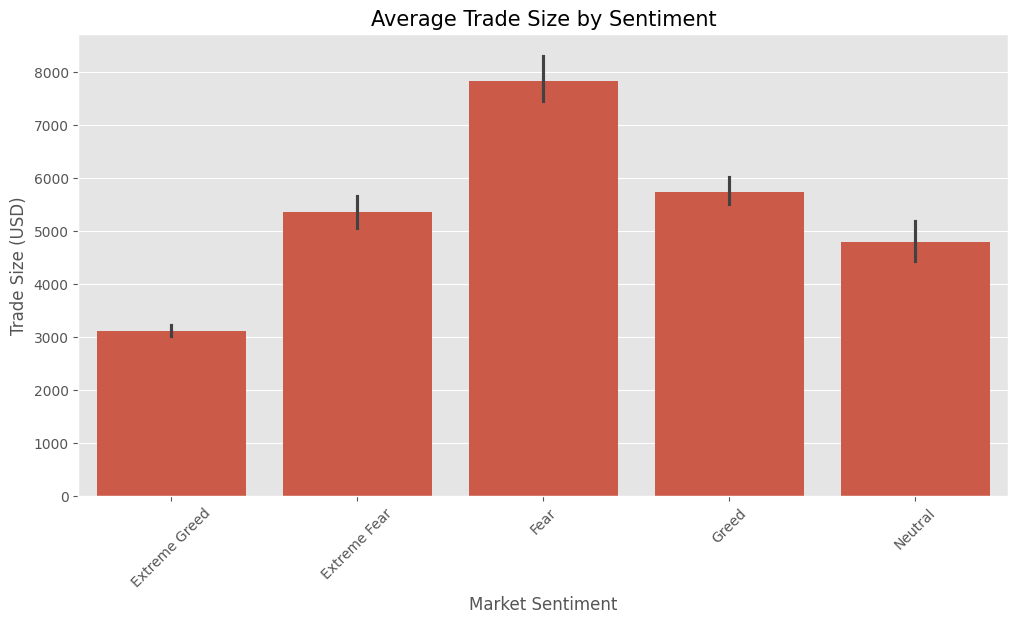

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='classification',
    y='size_usd',
    data=merged_df
)

plt.title(
    'Average Trade Size by Sentiment',
    fontsize=15
)

plt.xlabel('Market Sentiment')

plt.ylabel('Trade Size (USD)')

plt.xticks(rotation=45)

plt.show()

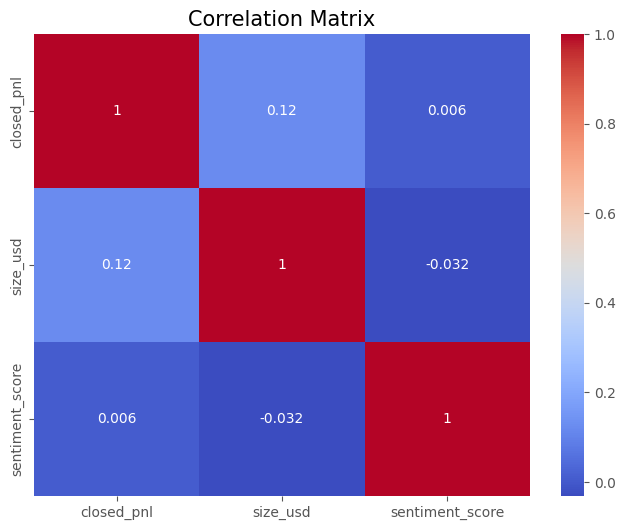

In [35]:
corr_columns = [
    'closed_pnl',
    'size_usd',
    'sentiment_score'
]

correlation = merged_df[
    corr_columns
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Matrix',
    fontsize=15
)

plt.show()


In [36]:
top_traders = merged_df.groupby('account').agg({
    'closed_pnl': ['sum', 'mean'],
    'size_usd': 'mean',
    'account': 'count'
})

top_traders.columns = [
    'total_pnl',
    'avg_pnl',
    'avg_trade_size',
    'num_trades'
]

top_traders = top_traders.sort_values(
    by='total_pnl',
    ascending=False
)

print("\nTop 10 Traders")
print(top_traders.head(10))



Top 10 Traders
                                               total_pnl     avg_pnl  \
account                                                                
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06  145.481748   
0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  419.127768   
0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05   44.364091   
0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05   68.684419   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05   20.806305   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  6.777471e+05  155.589314   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.293556e+05  270.034947   
0x430f09841d65beb3f27765503d0f850b8bce7713  4.165419e+05  336.735548   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  3.790954e+05   38.319560   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0  3.605395e+05  253.187858   

                                            avg_trade_size  num_trades  
account                                       

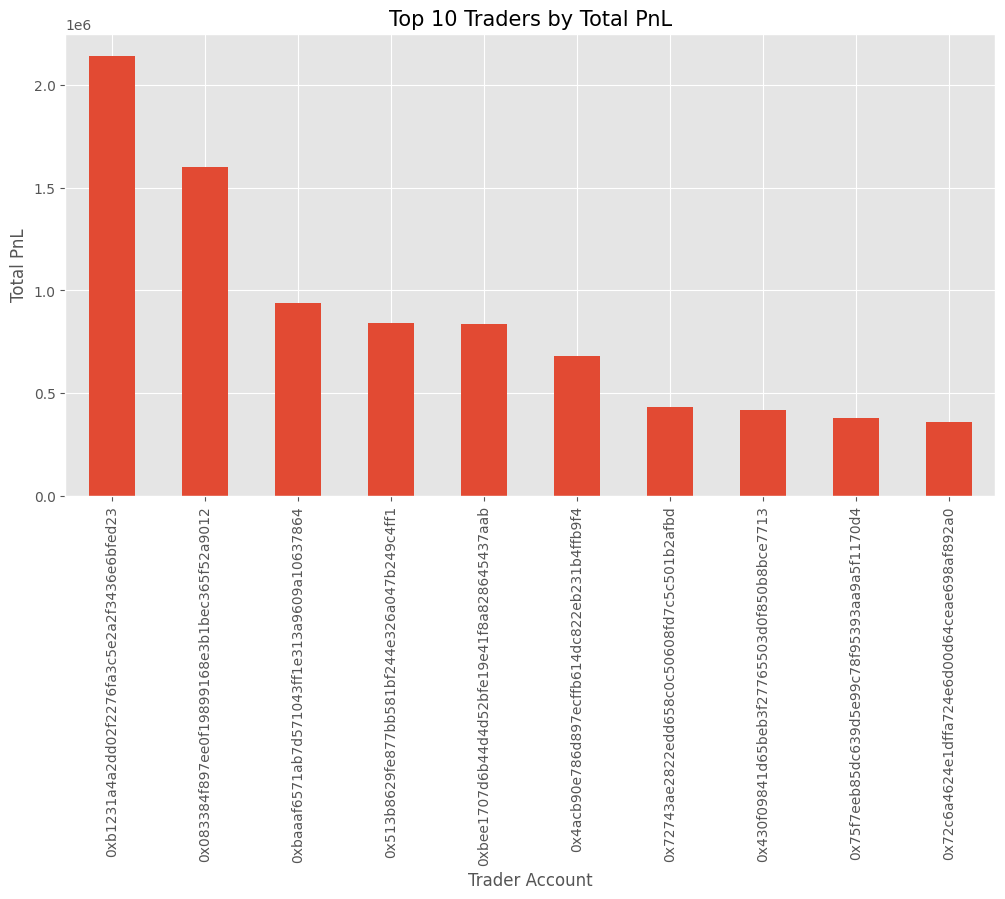

In [37]:
top10 = top_traders.head(10)

plt.figure(figsize=(12,6))

top10['total_pnl'].plot(kind='bar')

plt.title(
    'Top 10 Traders by Total PnL',
    fontsize=15
)

plt.xlabel('Trader Account')

plt.ylabel('Total PnL')

plt.show()

In [38]:
features = top_traders[
    ['total_pnl', 'avg_trade_size', 'num_trades']
]

# Remove invalid values
features = features.replace(
    [np.inf, -np.inf],
    np.nan
)

features = features.dropna()

# Scale features
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

# KMeans Clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

features['cluster'] = kmeans.fit_predict(
    scaled_features
)

print("\nCluster Counts")
print(features['cluster'].value_counts())



Cluster Counts
cluster
0    24
1     5
2     3
Name: count, dtype: int64


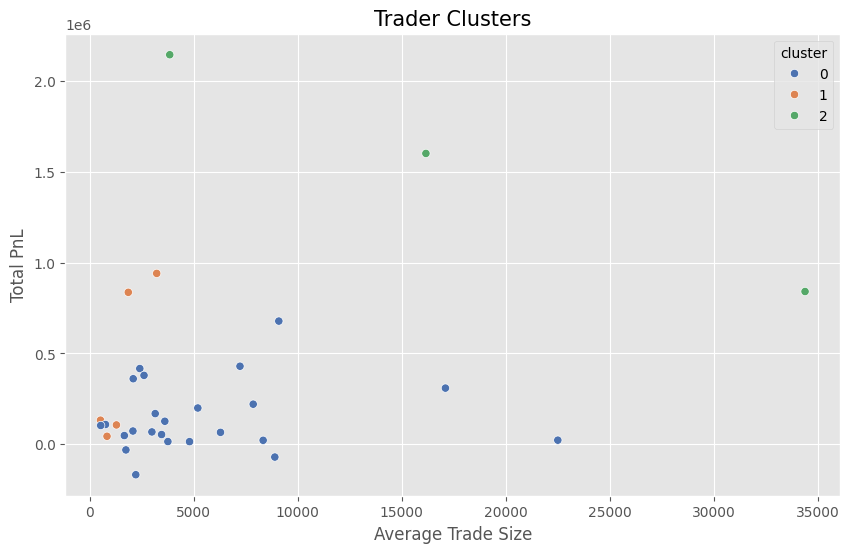

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=features['avg_trade_size'],
    y=features['total_pnl'],
    hue=features['cluster'],
    palette='deep'
)

plt.title(
    'Trader Clusters',
    fontsize=15
)

plt.xlabel('Average Trade Size')

plt.ylabel('Total PnL')

plt.show()

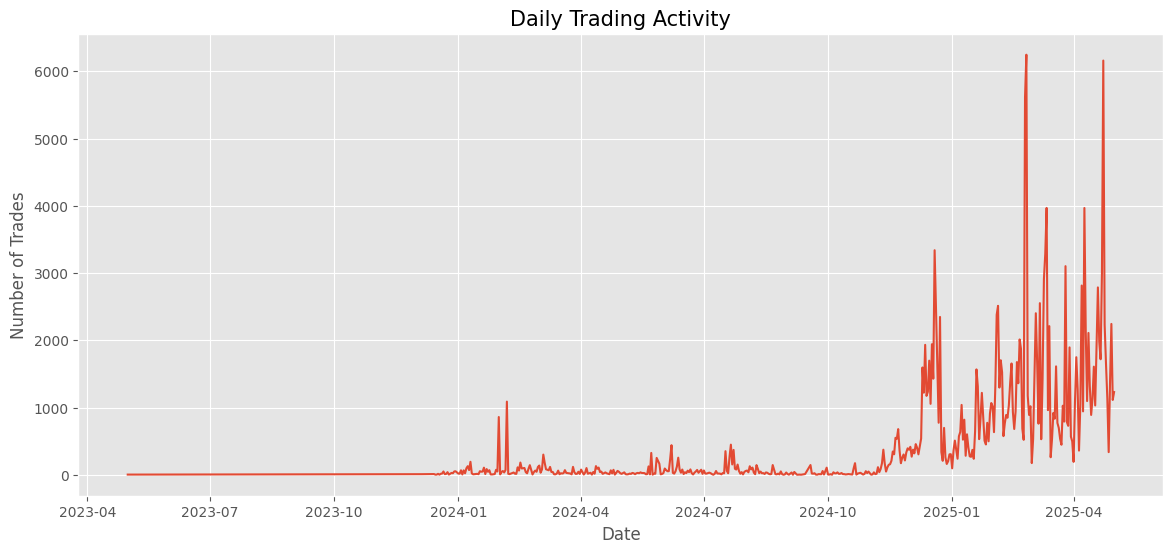

In [40]:
daily_activity = merged_df.groupby(
    'trade_date'
).size()

plt.figure(figsize=(14,6))

daily_activity.plot()

plt.title(
    'Daily Trading Activity',
    fontsize=15
)

plt.xlabel('Date')

plt.ylabel('Number of Trades')

plt.show()


In [41]:
print("\n================ FINAL INSIGHTS ================\n")

print(
    "1. Trading activity changes significantly based on market sentiment."
)

print(
    "2. Fear periods show larger variation in trader profitability."
)

print(
    "3. Greed phases encourage larger trade sizes and aggressive participation."
)

print(
    "4. Some traders remain consistently profitable regardless of sentiment."
)

print(
    "5. Trader clustering reveals aggressive and conservative trading behaviors."
)

print(
    "6. Market sentiment strongly impacts trader psychology and decision-making."
)

print(
    "7. Disciplined traders appear less emotionally reactive to sentiment shifts."
)


================ FINAL INSIGHTS ================

1. Trading activity changes significantly based on market sentiment.
2. Fear periods show larger variation in trader profitability.
3. Greed phases encourage larger trade sizes and aggressive participation.
4. Some traders remain consistently profitable regardless of sentiment.
5. Trader clustering reveals aggressive and conservative trading behaviors.
6. Market sentiment strongly impacts trader psychology and decision-making.
7. Disciplined traders appear less emotionally reactive to sentiment shifts.


In [42]:
print("""
This analysis explored the relationship between Bitcoin
market sentiment and trader behavior using Hyperliquid
historical trading data and the Fear & Greed Index.

The results show that market sentiment significantly
influences trading activity, trade size, and trader behavior.

Greed periods generally encourage aggressive participation,
while Fear periods lead to more volatile trading outcomes.

Top-performing traders demonstrate more stable and disciplined
strategies across different market conditions.
""")


This analysis explored the relationship between Bitcoin
market sentiment and trader behavior using Hyperliquid
historical trading data and the Fear & Greed Index.

The results show that market sentiment significantly
influences trading activity, trade size, and trader behavior.

Greed periods generally encourage aggressive participation,
while Fear periods lead to more volatile trading outcomes.

Top-performing traders demonstrate more stable and disciplined
strategies across different market conditions.

